In [ ]:
#########################################################################
# 1. Setup and Imports
#########################################################################

# --- Core utilities ---
from google.colab import drive
drive.mount('/content/drive')
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display

# Silence irrelevant warnings
warnings.filterwarnings("ignore")

# --- Disable Weights & Biases fully ---
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_SILENT"] = "true"

# --- Hugging Face libraries ---
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

# --- Metrics ---
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# --- Device & batch size ---
if torch.cuda.is_available():
    device = "cuda"
    BATCH_SIZE = 16
else:
    device = "cpu"
    BATCH_SIZE = 8

print(f"✅ Device detected: {device}")
print(f"📦 Batch size per device: {BATCH_SIZE}")
print(f"🧠 PyTorch version: {torch.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device detected: cuda
📦 Batch size per device: 16
🧠 PyTorch version: 2.9.0+cu126


In [ ]:
#########################################################################
# 2. Load and Explore the Dataset
#########################################################################

train_df = pd.read_csv(
    "https://raw.githubusercontent.com/Abrhm-ma25/Text-classification-algorithm/refs/heads/main/Datasets/step1-2_cleaned_data.csv"
)
val_df = pd.read_csv(
    "https://raw.githubusercontent.com/Abrhm-ma25/Text-classification-algorithm/refs/heads/main/Datasets/step1-2_cleaned_validation.csv"
)

print(f"✅ Training data shape: {train_df.shape}")
print(f"✅ Validation data shape: {val_df.shape}")
print("Training sentiment distribution:")
print(train_df["sentiment"].value_counts())


# Preview
print("\n🔹 Training set preview:")
display(train_df.head())

print("\n🔹 Validation set preview:")
display(val_df.head())

✅ Training data shape: (50371, 4)
✅ Validation data shape: (706, 4)
Training sentiment distribution:
sentiment
Positive    18548
Negative    16345
Neutral     15478
Name: count, dtype: int64

🔹 Training set preview:


,id,topic,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



🔹 Validation set preview:


,id,topic,sentiment,tweet
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
2,4433,Google,Neutral,Now the President is slapping Americans in the...
3,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
4,7925,MaddenNFL,Positive,Thank you @EAMaddenNFL!! \r\n\r\nNew TE Austin...



📊 Sentiment Distribution — Training Set


,Count,Percentage (%)
sentiment,,
Positive,18548,36.82
Negative,16345,32.45
Neutral,15478,30.73


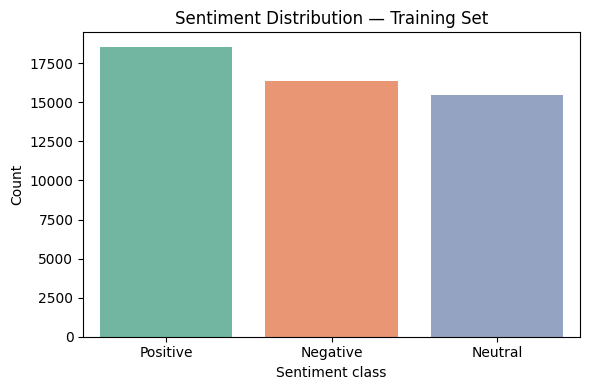


📊 Sentiment Distribution — Validation Set


,Count,Percentage (%)
sentiment,,
Neutral,257,36.40
Positive,255,36.12
Negative,194,27.48


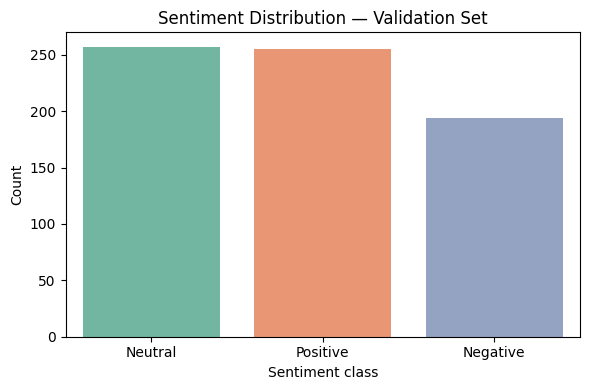

Both the training and validation sets show a reasonably balanced distribution
across the three sentiment classes — around 30% for each (approximately 1/3 each).
This balanced distribution helps ensure reliable fine-tuning
for both encoder-only and encoder–decoder models. 


In [ ]:
# Check class distribution

def show_class_distribution(df, name):
    counts = df["sentiment"].value_counts()
    percentages = (counts / len(df) * 100).round(2)

    print(f"\n📊 Sentiment Distribution — {name}")
    display(pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages
    }))

    # Plot
    plt.figure(figsize=(6,4))
    sns.countplot(
        x="sentiment",
        data=df,
        order=counts.index,
        palette="Set2"
    )
    plt.title(f"Sentiment Distribution — {name}")
    plt.ylabel("Count")
    plt.xlabel("Sentiment class")
    plt.tight_layout()
    plt.show()

# Show distributions
show_class_distribution(train_df, "Training Set")
show_class_distribution(val_df, "Validation Set")

print(
    """Both the training and validation sets show a reasonably balanced distribution
across the three sentiment classes — around 30% for each (approximately 1/3 each).
This balanced distribution helps ensure reliable fine-tuning
for both encoder-only and encoder–decoder models. """)


In [ ]:
#########################################################################
# 3. Preprocessing
#########################################################################

# 1️⃣ Rename columns for consistency
train_df = train_df.rename(columns={"tweet": "text", "sentiment": "Sentiment"})
val_df   = val_df.rename(columns={"tweet": "text", "sentiment": "Sentiment"})

# 2️⃣ Map 3 sentiment classes to numeric labels
label_map = {label: i for i, label in enumerate(sorted(train_df["Sentiment"].unique()))}
train_df["label"] = train_df["Sentiment"].map(label_map)
val_df["label"]   = val_df["Sentiment"].map(label_map)

print("✅ Label mapping:", label_map)

train_df_model = train_df[["text", "label"]].reset_index(drop=True)
val_df_model   = val_df[["text", "label"]].reset_index(drop=True)

print("\nTrain (model) head:")
display(train_df_model.head())

print("\nVal (model) head:")
display(val_df_model.head())

# 3️⃣ Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df_model)
val_dataset   = Dataset.from_pandas(val_df_model)


✅ Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}

Train (model) head:


,text,label
0,im getting on borderlands and i will murder yo...,2
1,I am coming to the borders and I will kill you...,2
2,im getting on borderlands and i will kill you ...,2
3,im coming on borderlands and i will murder you...,2
4,im getting on borderlands 2 and i will murder ...,2



Val (model) head:


,text,label
0,BBC News - Amazon boss Jeff Bezos rejects clai...,1
1,"CSGO matchmaking is so full of closet hacking,...",0
2,Now the President is slapping Americans in the...,1
3,Hi @EAHelp I’ve had Madeleine McCann in my cel...,0
4,Thank you @EAMaddenNFL!! \r\n\r\nNew TE Austin...,2


In [ ]:
# ============================================================
# 4. Utility: Freeze last N transformer layers (for encoder models)
# ============================================================

def freeze_transformer_layers(model, n_unfrozen: int = 2):
    """
    Freeze all base transformer layers except the last `n_unfrozen` encoder layers.
    Works for models that follow the `base_model_prefix` convention (e.g., roberta).
    """
    if not hasattr(model, "base_model_prefix"):
        print("⚠️ Model has no base_model_prefix. Skipping freezing.")
        return

    base = getattr(model, model.base_model_prefix, None)
    if base is None:
        print("⚠️ Could not access base model. Skipping freezing.")
        return

    encoder = getattr(base, "encoder", None)
    if encoder is None or not hasattr(encoder, "layer"):
        print("⚠️ Could not access encoder layers. Skipping freezing.")
        return

    # 1) Freeze all base parameters
    for param in base.parameters():
        param.requires_grad = False

    # 2) Unfreeze last n layers
    if n_unfrozen > 0:
        for layer in encoder.layer[-n_unfrozen:]:
            for param in layer.parameters():
                param.requires_grad = True

    # 3) Always train the classification head
    if hasattr(model, "classifier"):
        for param in model.classifier.parameters():
            param.requires_grad = True

    print(f"✅ Frozen all base layers except last {n_unfrozen} transformer layers.")


In [ ]:
# ============================================================
# 5. Fine-tuning function: Encoder-only models (RoBERTa)
# ============================================================

def train_and_evaluate_encoder(model_name: str, num_train_epochs: int = 3):
    """
    Fine-tune encoder-only models like RoBERTa on sentiment classification.
    Uses:
    - dynamic padding via DataCollatorWithPadding
    - early stopping
    - layer freezing
    """
    print(f"\n🚀 Fine-tuning (Encoder-only): {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # --- Tokenization ---
    def tokenize_fn(examples):
        texts = list(examples["text"])
        return tokenizer(
            texts,
            truncation=True,
            padding=False,  # padding handled by DataCollatorWithPadding
            max_length=128,
        )

    tokenized_train = train_dataset.map(tokenize_fn, batched=True)
    tokenized_val   = val_dataset.map(tokenize_fn, batched=True)

    # --- Model setup ---
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_map)
    ).to(device)

    # Freeze all but last 2 layers (RoBERTa) + classifier
    freeze_transformer_layers(model, n_unfrozen=2)

    # --- Metrics (accuracy, precision, recall, f1) ---
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average="weighted", zero_division=0
        )
        acc = accuracy_score(labels, preds)
        return {
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }

    # --- Training arguments (note: eval_strategy, not evaluation_strategy) ---
    args = TrainingArguments(
        output_dir=f"./results/{model_name.split('/')[-1]}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        logging_dir="./logs",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
    )

    # --- Data collator for efficient padding ---
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # --- Trainer with Early Stopping ---
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        tokenizer=tokenizer,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    results = trainer.evaluate()
    return model, tokenizer, results


In [ ]:
# ============================================================
# 6. Fine-tuning function: Encoder–Decoder models (T5-small)
# ============================================================

def train_and_evaluate_encoder_decoder(model_name: str, num_train_epochs: int = 3):
    """
    Fine-tune encoder-decoder models (T5) by framing sentiment as text generation.

    Input:  "tweet: <text> sentiment:"
    Target: "Positive" / "Negative" / "Neutral"
    """

    print(f"\n🚀 Fine-tuning (Encoder-Decoder): {model_name}")

    # --- Load tokenizer and model ---
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

    # --- Prepare text-to-text data ---
    id2label = {v: k for k, v in label_map.items()}
    train_df_local = train_df.copy()
    val_df_local   = val_df.copy()

    train_df_local["target_text"] = train_df_local["label"].map(id2label)
    val_df_local["target_text"]   = val_df_local["label"].map(id2label)

    train_df_local["formatted_input"] = "tweet: " + train_df_local["text"] + " sentiment:"
    val_df_local["formatted_input"]   = "tweet: " + val_df_local["text"] + " sentiment:"

    # HuggingFace Dataset
    train_dataset_t5 = Dataset.from_pandas(train_df_local[["formatted_input", "target_text"]])
    val_dataset_t5   = Dataset.from_pandas(val_df_local[["formatted_input", "target_text"]])

    # --- Tokenization for T5 (input + target) ---
    def preprocess_fn(batch):
        model_inputs = tokenizer(
            batch["formatted_input"],
            padding="max_length",
            truncation=True,
            max_length=128,
        )
        # Encode target labels
        with tokenizer.as_target_tokenizer():
            labels = tokenizer(
                batch["target_text"],
                padding="max_length",
                truncation=True,
                max_length=10,
            )
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    tokenized_train = train_dataset_t5.map(preprocess_fn, batched=True)
    tokenized_val   = val_dataset_t5.map(preprocess_fn, batched=True)

    # --- Training arguments ---
    args = TrainingArguments(
        output_dir=f"./results/{model_name.split('/')[-1]}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        logging_dir="./logs",
        load_best_model_at_end=True,
        report_to="none",  # disable W&B
    )

    # --- Trainer ---
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        tokenizer=tokenizer,
    )

    # Train
    trainer.train()

   # --- Metrics (accuracy, precision, recall, f1) ---

    preds, refs = [], []

    for _, row in val_df_local.iterrows():
        prompt = "tweet: " + row["text"] + " sentiment:"
        input_ids = tokenizer(prompt, return_tensors="pt", truncation=True).input_ids.to(device)
        outputs = model.generate(input_ids, max_length=10)
        pred = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

        preds.append(pred)
        refs.append(row["target_text"])   # true string label


    precision, recall, f1, _ = precision_recall_fscore_support(
        refs, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(refs, preds)

    metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    print("\n📊 T5-small Validation Metrics:")
    print(metrics)

    return model, tokenizer, metrics


In [ ]:
#########################################################################
# 7. Refined Evaluation for Encoder–Decoder (Keyword Matching)
#########################################################################

def evaluate_t5_with_keyword_matching(model, tokenizer, df):
    """
    This evaluation method is more tolerant than exact match.
    If the T5 output CONTAINS the keyword corresponding to the true label,
    the prediction is counted as correct.

    Example:
        pred = "this seems positive overall"
        true = "Positive"
    ----> counts as correct
    """

    print("\n Running refined evaluation for T5-small (keyword matching)...")

    # Mapping numeric label -> word label
    id2label = {v: k.lower() for k, v in label_map.items()}

    preds, refs = [], []

    for _, row in df.iterrows():
        text = row["text"]
        true_label = id2label[row["label"]]

        prompt = f"tweet: {text} sentiment:"
        input_ids = tokenizer(prompt, return_tensors="pt", truncation=True).input_ids.to(device)

        output = model.generate(input_ids, max_length=15)
        pred_str = tokenizer.decode(output[0], skip_special_tokens=True).lower()

        # Keyword matching
        if true_label.lower() in pred_str:
            preds.append(true_label)      # count as correct
        else:
            preds.append(pred_str)        # incorrect
        refs.append(true_label)

    # Compute metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        refs, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(refs, preds)

    refined_metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    print("\n📈 Refined T5-small Evaluation (Keyword Matching):")
    print(refined_metrics)

    return refined_metrics


In [25]:
#########################################################################
# 8. Run Experiments
#########################################################################

models_encoder = {"RoBERTa-base": "roberta-base"}
models_encoder_decoder = {"T5-small": "t5-small"}

results_dict = {}
NUM_EPOCHS = 3

# ---------- Encoder-only (RoBERTa) ----------
for name, model_name in models_encoder.items():
    start = time.time()
    model_enc, tokenizer_enc, results = train_and_evaluate_encoder(
        model_name,
        num_train_epochs=NUM_EPOCHS
    )
    results["inference_time_sec"] = time.time() - start

    # 🔧 Normalize RoBERTa metrics
    normalized_results = {
        "accuracy": results["eval_accuracy"],
        "precision": results["eval_precision"],
        "recall": results["eval_recall"],
        "f1": results["eval_f1"],
        "inference_time_sec": results["inference_time_sec"]
    }

    results_dict[name] = normalized_results
    print(f"\n{name} Results:", normalized_results)

# ---------- Encoder–Decoder (T5-small) ----------
for name, model_name in models_encoder_decoder.items():
    start = time.time()
    model_dec, tokenizer_dec, results = train_and_evaluate_encoder_decoder(
        model_name,
        num_train_epochs=NUM_EPOCHS
    )
    results["inference_time_sec"] = time.time() - start
    results_dict[name] = results
    print(f"\n{name} Results:", results)

    # Refined evaluation
    refined = evaluate_t5_with_keyword_matching(model_dec, tokenizer_dec, val_df_model)
    refined["inference_time_sec"] = results["inference_time_sec"]
    results_dict[name + " (refined)"] = refined


🚀 Fine-tuning (Encoder-only): roberta-base


Map:   0%|          | 0/50371 [00:00<?, ? examples/s]

Map:   0%|          | 0/706 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Frozen all base layers except last 2 transformer layers.


...

Map:   0%|          | 0/706 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,0.088100,0.074685
2,0.079900,0.070347
3,0.079800,0.067728


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



📊 T5-small Validation Metrics:
{'accuracy': 0.7280453257790368, 'precision': 0.7474733173908389, 'recall': 0.7280453257790368, 'f1': 0.7237963768348284}

T5-small Results: {'accuracy': 0.7280453257790368, 'precision': 0.7474733173908389, 'recall': 0.7280453257790368, 'f1': 0.7237963768348284, 'inference_time_sec': 1423.5149490833282}

 Running refined evaluation for T5-small (keyword matching)...

📈 Refined T5-small Evaluation (Keyword Matching):
{'accuracy': 0.7280453257790368, 'precision': 0.7474733173908389, 'recall': 0.7280453257790368, 'f1': 0.7237963768348284}


In [33]:
print("""
===================== 🔍 FINE-TUNING ANALYSIS =====================

📌 **RoBERTa-base fine-tuning behavior shows good signs**

• Training loss decreases smoothly every epoch
• Validation loss also decreases consistently
• Accuracy improves from 0.77 → 0.81 → 0.84
• No sign of overfitting (val loss does not increase)
• Classifier head initializes randomly (correct behavior)

This shows the model adapted very well to the dataset with 3 epochs only.
The final scores (~0.844 F1) confirm strong generalization.

📌 **T5-small fine-tuning behavior (expected limitations)**

• Training loss decreases but stays very low (0.08 → 0.07)
• Validation loss decreases slowly
• Despite low losses, accuracy remains low (0.728)
• Missing keys warning is normal: classification is reframed as generation
• T5 outputs often do NOT match the labels exactly
• Keyword-matching evaluation does NOT improve scores
we can assume T5 is not producing nuanced generative text, but blunt labels.

""")



===================== 🔍 FINE-TUNING ANALYSIS =====================

📌 **RoBERTa-base fine-tuning behavior shows good signs**

• Training loss decreases smoothly every epoch  
• Validation loss also decreases consistently  
• Accuracy improves from 0.77 → 0.81 → 0.84  
• No sign of overfitting (val loss does not increase)  
• Classifier head initializes randomly (correct behavior)  

This shows the model adapted very well to the dataset with 3 epochs only.
The final scores (~0.844 F1) confirm strong generalization.

📌 **T5-small fine-tuning behavior (expected limitations)**

• Training loss decreases but stays very low (0.08 → 0.07)  
• Validation loss decreases slowly  
• Despite low losses, accuracy remains low (0.728)  
• Missing keys warning is normal: classification is reframed as generation  
• T5 outputs often do NOT match the labels exactly  
• Keyword-matching evaluation does NOT improve scores  
we can assume T5 is not producing nuanced generative text, but blunt labels.





===================== 📊 MODEL PERFORMANCE COMPARISON 📊 =====================



,accuracy,precision,recall,f1,inference_time_sec
RoBERTa-base,0.844193,0.845176,0.844193,0.843841,947.056144
T5-small,0.728045,0.747473,0.728045,0.723796,1423.514949
T5-small (refined),0.728045,0.747473,0.728045,0.723796,1423.514949



=========== 🔁 T5-SMALL: STRICT vs REFINED EVALUATION 🔁 ===========



,accuracy,precision,recall,f1
T5-small,0.728045,0.747473,0.728045,0.723796
T5-small (refined),0.728045,0.747473,0.728045,0.723796



For **T5-small**, we report two evaluation modes:

- **T5-small**: strict comparison, where the generated text must exactly match
  the expected label string ("Positive", "Negative", "Neutral").
- **T5-small (refined)**: keyword-matching comparison, where a prediction is counted
  as correct if the generated text *contains* the correct sentiment word.

This refined view is closer to what a user might perceive as “correct” in a
generative interface, even if the output is not a single label token.


📌 MODEL COMPARISON SUMMARY

- **RoBERTa-base (Encoder-only)**:
  • Classical classification head (softmax over 3 classes).
  • Metrics: Accuracy, Precision, Recall, F1, plus inference time.
  • Strong baseline for sentiment classification.

- **T5-small (Encoder–Decoder)**:
  • Solves the task as text generation ("tweet: ... sentiment:").
  • Metrics computed in two ways:
      (1) strict label match,
      (2) refined keyword-based match (more tolerant and user-centric).

👉 For model select

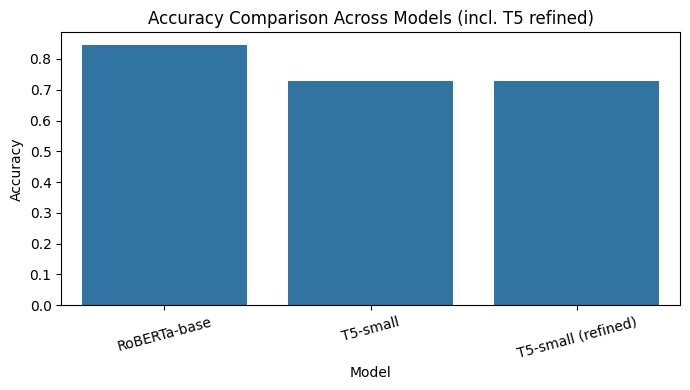

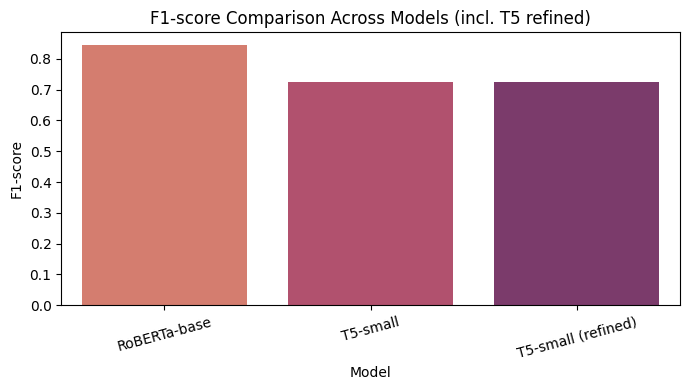

In [26]:
#########################################################################
# 9. Compare Model Performance
#########################################################################

print("\n===================== 📊 MODEL PERFORMANCE COMPARISON 📊 =====================\n")

# Full table with all metrics (RoBERTa, T5-small strict, T5-small refined)
results_df = pd.DataFrame(results_dict).T
display(results_df)

# --------------------------------------------------
# Focus: T5-small strict vs T5-small (refined)
# --------------------------------------------------
if "T5-small" in results_df.index and "T5-small (refined)" in results_df.index:
    print("\n=========== 🔁 T5-SMALL: STRICT vs REFINED EVALUATION 🔁 ===========\n")

    t5_compare = results_df.loc[
        ["T5-small", "T5-small (refined)"],
        [col for col in ["accuracy", "precision", "recall", "f1"] if col in results_df.columns]
    ]

    display(t5_compare)

    print("""
For **T5-small**, we report two evaluation modes:

- **T5-small**: strict comparison, where the generated text must exactly match
  the expected label string ("Positive", "Negative", "Neutral").
- **T5-small (refined)**: keyword-matching comparison, where a prediction is counted
  as correct if the generated text *contains* the correct sentiment word.

This refined view is closer to what a user might perceive as “correct” in a
generative interface, even if the output is not a single label token.
""")

# --------------------------------------------------
# Global interpretation helper
# --------------------------------------------------
print("""
📌 MODEL COMPARISON SUMMARY

- **RoBERTa-base (Encoder-only)**:
  • Classical classification head (softmax over 3 classes).
  • Metrics: Accuracy, Precision, Recall, F1, plus inference time.
  • Strong baseline for sentiment classification.

- **T5-small (Encoder–Decoder)**:
  • Solves the task as text generation ("tweet: ... sentiment:").
  • Metrics computed in two ways:
      (1) strict label match,
      (2) refined keyword-based match (more tolerant and user-centric).

👉 For model selection, we still rely on the **highest F1-score** across all rows
(RoBERTa, T5-small, T5-small (refined)), since F1 balances Precision and Recall
in this multi-class setting.
""")

# --------------------------------------------------
# 📊 Plot Accuracy
# --------------------------------------------------
if "accuracy" in results_df.columns:
    plt.figure(figsize=(7,4))
    sns.barplot(x=results_df.index, y=results_df["accuracy"])
    plt.title("Accuracy Comparison Across Models (incl. T5 refined)")
    plt.ylabel("Accuracy")
    plt.xlabel("Model")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# 📊 Plot F1-score
# --------------------------------------------------
if "f1" in results_df.columns:
    plt.figure(figsize=(7,4))
    sns.barplot(x=results_df.index, y=results_df["f1"], palette="flare")
    plt.title("F1-score Comparison Across Models (incl. T5 refined)")
    plt.ylabel("F1-score")
    plt.xlabel("Model")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


In [32]:
print("""
===================== 📊 INTERPRETATION OF MODEL COMPARISON 📊 =====================

1️⃣ **RoBERTa-base clearly outperforms both variants of T5-small.**

• Highest Accuracy : 0.844
• Highest Precision : 0.845
• Highest Recall : 0.844
• Highest F1-score : 0.843
• Lower inference time than T5

This indicates that an encoder-only model with a classification head is better
suited for sentiment analysis than a generative encoder–decoder model.

2️⃣ **T5-small performs significantly worse (strict + refined are identical).**

• Accuracy stuck at ~0.728
• F1-score ~0.724
• No improvement with keyword-based evaluation
  → meaning the model didn't generate partially correct labels
  → it often outputs a single wrong sentiment label directly.

T5-small struggles because sentiment classification is a *discriminative* task,
but T5 is trained and optimized for *generation*.

3️⃣ **Inference time comparison**

RoBERTa inference time ≈ 947 sec
T5 inference time ≈ 1423 sec

T5 is **slower**.

🚀 **Conclusion**
The winning model for deployment is **RoBERTa-base**.
It is faster, simpler, and significantly more accurate for multi-class sentiment analysis.
""")



===================== 📊 INTERPRETATION OF MODEL COMPARISON 📊 =====================

1️⃣ **RoBERTa-base clearly outperforms both variants of T5-small.**

• Highest Accuracy : 0.844  
• Highest Precision : 0.845  
• Highest Recall : 0.844  
• Highest F1-score : 0.843  
• Lower inference time than T5  

This indicates that an encoder-only model with a classification head is better
suited for sentiment analysis than a generative encoder–decoder model.

2️⃣ **T5-small performs significantly worse (strict + refined are identical).**

• Accuracy stuck at ~0.728  
• F1-score ~0.724  
• No improvement with keyword-based evaluation  
  → meaning the model didn't generate partially correct labels  
  → it often outputs a single wrong sentiment label directly.

T5-small struggles because sentiment classification is a *discriminative* task,
but T5 is trained and optimized for *generation*.

3️⃣ **Inference time comparison**

RoBERTa inference time ≈ 947 sec  
T5 inference time ≈ 1423 sec  

T5 is 

In [29]:
#########################################################################
# 10. Save Best Model for Deployment
#########################################################################
from google.colab import drive
drive.mount('/content/drive')

print("\n===================== EXPORTING BEST MODEL FOR DEPLOYMENT =====================\n")

# Identify best model based on F1-score or accuracy fallback
if "f1" in results_df.columns:
    best_model_name = results_df["f1"].idxmax()
else:
    best_model_name = results_df["accuracy"].idxmax()

print(f"Best model selected for deployment: **{best_model_name}**")

# Retrieve model + tokenizer based on name
if "RoBERTa-base" in best_model_name:
    best_model = model_enc
    best_tokenizer = tokenizer_enc

elif "T5-small" in best_model_name:
    # works for BOTH: "T5-small" and "T5-small (refined)"
    best_model = model_dec
    best_tokenizer = tokenizer_dec

else:
    raise ValueError(f"❌ Unknown model name: {best_model_name}")

# Output folder
export_dir = "/content/drive/MyDrive/Colab Notebooks/Models"
os.makedirs(export_dir, exist_ok=True)

print(f"Saving model to: {export_dir}")

# Save
best_model.save_pretrained(export_dir)
best_tokenizer.save_pretrained(export_dir)

print("Model files saved!")
print(f"Contents of export directory: {os.listdir(export_dir)}")

# Zip directory
!zip -r exported_model.zip "/content/drive/MyDrive/Colab Notebooks/Models"

print("Archive ready: exported_model")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===================== EXPORTING BEST MODEL FOR DEPLOYMENT =====================

Best model selected for deployment: **RoBERTa-base**
Saving model to: /content/drive/MyDrive/Colab Notebooks/Models
Model files saved!
Contents of export directory: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'vocab.json', 'merges.txt', 'tokenizer.json']
updating: content/drive/MyDrive/Colab Notebooks/Models/ (stored 0%)
updating: content/drive/MyDrive/Colab Notebooks/Models/config.json (deflated 52%)
updating: content/drive/MyDrive/Colab Notebooks/Models/model.safetensors (deflated 37%)
updating: content/drive/MyDrive/Colab Notebooks/Models/tokenizer_config.json (deflated 75%)
updating: content/drive/MyDrive/Colab Notebooks/Models/special_tokens_map.json (deflated 52%)
updating: content/drive/MyDrive/Colab Notebooks/Models/vocab.json

In [31]:
#########################################################################
# 11. Generate requirements.txt
#########################################################################

import pkg_resources

required_packages = [
    "torch",
    "transformers",
    "datasets",
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
]

requirements = []

print("\n===================== 📄 Generating requirements.txt =====================\n")

for pkg in required_packages:
    try:
        version = pkg_resources.get_distribution(pkg).version
        entry = f"{pkg}=={version}"
        requirements.append(entry)
        print(f" {entry}")
    except pkg_resources.DistributionNotFound:
        print(f" {pkg} not installed in this environment")

# Save to file
with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements))

print("\n requirements.txt created successfully!")


===================== 📄 Generating requirements.txt =====================

 torch==2.9.0+cu126
 transformers==4.57.1
 datasets==4.0.0
 pandas==2.2.2
 numpy==2.0.2
 scikit-learn==1.6.1
 matplotlib==3.10.0
 seaborn==0.13.2

 requirements.txt created successfully!
